# Lab 5: 4-ASK and Envelope Detection

Every modulation scheme you build encodes information in some property of a transmitted
waveform: phase, amplitude, or some combination of the two. This lab isolates amplitude on
its own. You will send a 4-level amplitude-shift-keyed (4-ASK) signal from one
software-defined radio to another, and recover it using only the *magnitude* of what
arrives, never its phase.

That choice has a consequence worth noticing before you start. Two independent radios, each
running its own free-running local oscillator, will never agree perfectly on carrier phase or
frequency. A receiver that depends on phase has to actively track and correct for that
mismatch. A receiver that only looks at magnitude does not have to: the rotation is still
present in the raw samples, but it never touches the number you actually base a decision on.
You will see this directly, side by side, later in the lab: a raw IQ scatter that spirals, and
an amplitude histogram built from those same samples that does not.

Before any of that, though, every SDR receiver carries its own quiet, constant bias: a DC
offset baked into the hardware, present regardless of whatever is or isn't on the air.
Estimating and removing that offset is where this lab starts. 

*A suggestion is to use wired transmission for this experiment*

## Hardware Setup

Configure both radios: sample rate, carrier frequency, transmit scaling, and a fixed manual
receive gain. These values stay fixed for the rest of the lab, with one exception — the
transmit gain, which you will sweep deliberately in the final task.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import adi
import time

fs = int(1.0e6)
fc = int(3100e6)
tx_scale = 2**14

tx_sdr = adi.Pluto("ip:192.168.2.1")
rx_sdr = adi.Pluto("ip:192.168.3.1")

tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -10

rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 40
rx_sdr.rx_buffer_size = 30000

## Task 1: Calibrate the Receiver's DC Offset

Every SDR receiver reports a small, roughly constant complex bias even when nothing is being
transmitted — a mix of local-oscillator leakage into the receive path and imperfections in the
analog front end. Left uncorrected, this offset shifts every sample you capture later by the
same fixed amount, which will distort both the constellation you look at and the amplitude
decisions you eventually make.

Measure it directly. With the transmitter idle, capture a burst of receive samples. The very
first samples after a capture starts are often still settling, so discard an initial stretch
of them and average only what remains. The result is your estimate of the hardware's DC
offset: a single complex number you will subtract from every capture for the rest of this
lab.

In [2]:
tx_sdr.tx_destroy_buffer()
time.sleep(0.2)

rx_idle_raw = rx_sdr.rx()   # TODO: capture a burst of RX samples with the transmitter idle
dc_offset = np.mean(rx_idle_raw[1000:])      # TODO: average the settled portion of rx_idle_raw (discard the
                                             #       initial transient samples first)
rx_sdr.rx_destroy_buffer()

print(f"DC offset estimate: {dc_offset.real:.2f} + {dc_offset.imag:.2f}j")

DC offset estimate: -0.05 + 0.02j


## Task 2: Design the 4-ASK Constellation

Design four amplitude levels, equally spaced and all positive (unipolar), to represent the
four possible 2-bit symbol values. Scale them so the largest level is a modest fraction of the
transmitter's full output range, leaving headroom rather than driving the hardware at its
limit.

Assign each of the four amplitude levels a unique 2-bit label using Gray coding, so that any
two levels adjacent in magnitude differ in exactly one bit. Store the result in a form you can
look up both ways: from a 2-bit value to its transmit amplitude, and later, from a received
amplitude decision back to the 2 bits it represents.

In [3]:
ASK4_LEVELS = np.array([0.2, 0.4, 0.6, 0.8])   # TODO: four equally spaced, positive amplitude levels
ASK4_GRAY = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])      # TODO: 2-bit Gray-coded labels, in the same order as ASK4_LEVELS

## Task 3: Build the Transmit Frame

Choose a frame length: enough information bits that, even at a fairly low error rate, you can
expect to see enough errors later to estimate the bit error rate reliably. Tens of thousands
of bits is a reasonable starting point.

Generate that many random bits, group them into 2-bit symbols, and look up each symbol's
transmit amplitude from the mapping you built in Task 2. Turn each amplitude into a
rectangular pulse by holding it constant for a fixed number of samples per symbol. Hold on to
the original bit sequence — you will need it later to score errors.

In [4]:
sps = 32
n_bits = 1000            # TODO: choose a frame length (see above); must be even

tx_bits = np.random.randint(0, 2, n_bits)            # TODO: random array of n_bits bits (0s and 1s)

tx_symbols = np.array([
    np.where(np.all(ASK4_GRAY == pair, axis=1))[0][0]
    for pair in tx_bits.reshape(-1, 2)
])          # TODO: group tx_bits into 2-bit symbols (integer values 0-3)

tx_amplitudes = ASK4_LEVELS[tx_symbols]       # TODO: look up each symbol's amplitude from Task 2's mapping

start_symbols = np.ones(4)
start_waveform = np.repeat(start_symbols, sps)

data_waveform = np.repeat(tx_amplitudes, sps)

tx_waveform = (
    np.concatenate([start_waveform, data_waveform]) * tx_scale
).astype(np.complex64)          # TODO: hold each amplitude for sps samples to build the
                               #       rectangular pulse train (complex64)

## Task 4: Transmit and Capture

Size the receive buffer to comfortably hold at least one full frame with room to spare. Send
the waveform using a cyclic transmit buffer, so the frame repeats continuously while you
capture, then grab a burst of receive samples. As in Task 1, the very start of a capture is
still settling, so discard an initial stretch of it.

Before doing anything else with the captured samples, subtract the DC offset you measured in
Task 1. Every later step in this lab assumes that correction has already been applied.

In [5]:
rx_sdr.rx_buffer_size = 4 * len(tx_waveform) + 5000   # TODO: size the buffer to comfortably hold one frame

tx_sdr.tx_cyclic_buffer = True
tx_sdr.tx(tx_waveform)
time.sleep(0.5)

rx_raw = rx_sdr.rx()           # TODO: capture from rx_sdr
tx_sdr.tx_destroy_buffer()
rx_sdr.rx_destroy_buffer()

rx_calibrated = rx_raw[1000:] - dc_offset     # TODO: discard the initial transient, then apply the Task 1
                            #       DC-offset calibration to what remains

## Task 5: Envelope Detection and Symbol-Center Sampling

Take the magnitude of every calibrated received sample. This is the entire receiver: no phase
correction, no frequency correction, just magnitude.

A rectangular pulse holds a nearly constant amplitude for most of its duration, except right
at the transition to the next symbol. Rather than using every magnitude sample, pick one
representative sample from the middle of each symbol's pulse, spaced by your samples-per-symbol
value. Keep both the full magnitude sequence and this once-per-symbol sequence; you will need
the once-per-symbol version for detection, and the full sequence for a plot.

In [6]:
rx_envelope = np.abs(rx_calibrated)          # TODO: magnitude of every sample in rx_calibrated
rx_center_samples = rx_envelope[sps // 2::sps]     # TODO: one magnitude sample from the middle of every symbol's
                                #       pulse, sps samples apart

## Task 6: Visualize the Receiver Chain

Produce a single figure with three panels, side by side.

1. A scatter plot of the raw calibrated IQ samples, so you can see the shape any phase
   rotation between the two radios traces out.
2. A histogram of the once-per-symbol magnitude samples, so you can see whether four distinct
   amplitude levels are visible above the noise floor.
3. A time-domain plot of the envelope over the first few dozen symbols, with your
   once-per-symbol samples marked on top, so you can confirm you are sampling each pulse where
   its amplitude is most stable.

Label every axis and give each panel a title.

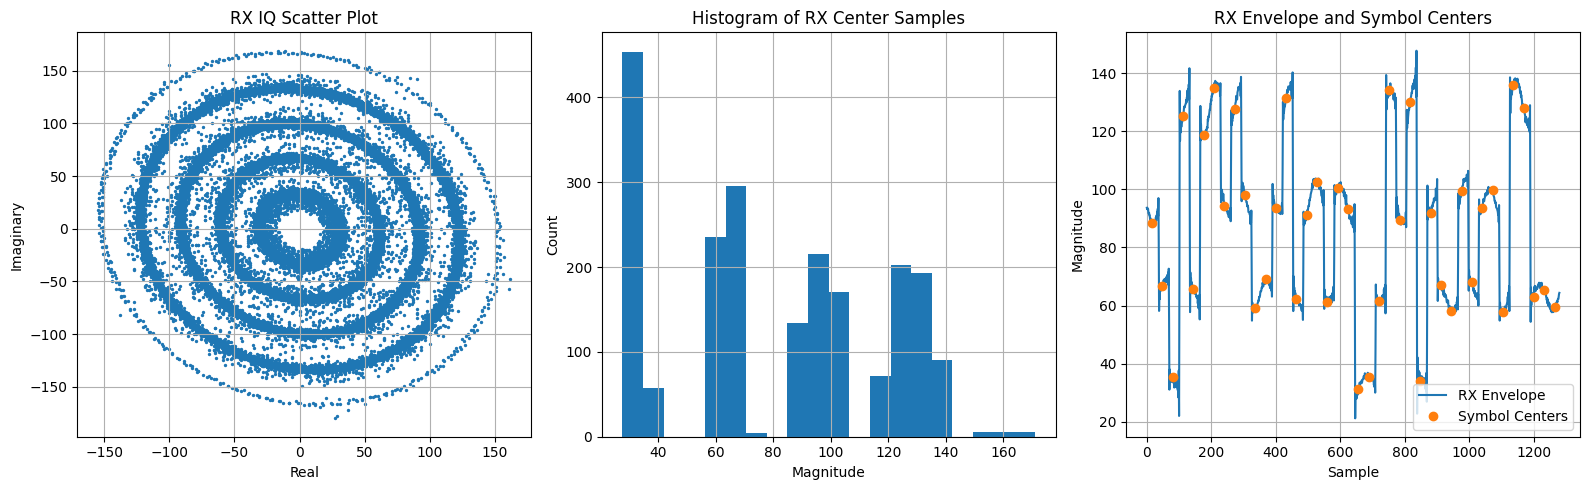

In [7]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.scatter(rx_calibrated.real, rx_calibrated.imag, s=2)   # TODO: scatter plot of rx_calibrated (real vs. imaginary), title, axis labels, grid
plt.title("RX IQ Scatter Plot")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(rx_center_samples, bins=20)   # TODO: histogram of rx_center_samples, title, axis labels, grid
plt.title("Histogram of RX Center Samples")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(1, 3, 3)
n_plot = min(len(rx_envelope), 40 * sps)
plt.plot(rx_envelope[:n_plot], label="RX Envelope")
plt.plot(
    np.arange(sps // 2, min(len(rx_center_samples), 40) * sps, sps),
    rx_center_samples[:min(len(rx_center_samples), 40)],
    "o",
    label="Symbol Centers"
)   # TODO: plot rx_envelope over its first several dozen symbols, with the
         #       corresponding rx_center_samples marked on top; title, axis labels, grid, legend
plt.title("RX Envelope and Symbol Centers")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Task 7: Amplitude Decision and Bit Recovery

Using the four ideal amplitude levels from Task 2 as reference points, decide which level each
value in your once-per-symbol sequence is closest to. Record that decision as a 2-bit symbol,
using the same Gray-coded mapping you built earlier, then concatenate the recovered symbols'
bits into one long sequence, in the same order the original bits were transmitted, so it can be
compared directly against your transmitted bit sequence.

In [8]:
from scipy.signal import find_peaks

# ---------------------------------------------------------
# Known frame parameters
# ---------------------------------------------------------

start_symbols = 4
start_length = start_symbols * sps

n_data_symbols = n_bits // 2
data_length = n_data_symbols * sps

frame_length = start_length + data_length

print("Expected frame length:", frame_length)

# ---------------------------------------------------------
# Find repeated START peaks
# ---------------------------------------------------------

# Moving average over exactly the START marker length
smooth = np.convolve(
    rx_envelope,
    np.ones(start_length) / start_length,
    mode="valid"
)

# Find peaks separated approximately by one complete frame.
# The START marker is amplitude 1.0, while data is <= 0.8.
peaks, properties = find_peaks(
    smooth,
    distance=int(0.8 * frame_length),
    prominence=0.1 * np.max(smooth)
)

print("Detected START peaks:", peaks)

# ---------------------------------------------------------
# We need two consecutive START peaks
# ---------------------------------------------------------

if len(peaks) < 2:
    raise ValueError(
        "Could not detect two START peaks. "
        "Check the RX envelope plot or increase RX buffer size."
    )

# Use the first pair of detected frame starts
start1 = peaks[0]
start2 = peaks[1]

print("START 1:", start1)
print("START 2:", start2)
print("Measured distance:", start2 - start1)
print("Expected distance:", frame_length)

# ---------------------------------------------------------
# Use the distance between START peaks as a sanity check
# ---------------------------------------------------------

if abs((start2 - start1) - frame_length) > 2 * sps:
    print(
        "WARNING: detected peak spacing differs from expected frame length."
    )

# ---------------------------------------------------------
# DATA starts after START 1
# ---------------------------------------------------------

data_start = start1 + start_length
data_end = data_start + data_length

print("Data start:", data_start)
print("Data end:", data_end)

# Make sure the complete frame is available
if data_end > len(rx_envelope):
    raise ValueError(
        "Not enough RX samples after START 1. "
        "Increase rx_sdr.rx_buffer_size."
    )

# ---------------------------------------------------------
# Extract exactly one DATA frame
# ---------------------------------------------------------

data_samples = rx_envelope[data_start:data_end]

# ---------------------------------------------------------
# Estimate received amplitude scale from START marker
# ---------------------------------------------------------

start_region = rx_envelope[
    start1 + sps :
    start1 + start_length - sps
]

if len(start_region) == 0:
    raise ValueError("START marker region is invalid.")

rx_full_scale = np.mean(start_region)

print("Received START amplitude:", rx_full_scale)

# Expected received ASK levels
rx_levels = ASK4_LEVELS * rx_full_scale

print("Received ASK levels:", rx_levels)

# ---------------------------------------------------------
# Midpoint thresholds
# ---------------------------------------------------------

thresholds = (
    rx_levels[:-1] + rx_levels[1:]
) / 2

print("Decision thresholds:", thresholds)

# ---------------------------------------------------------
# Extract one representative value from each symbol
# ---------------------------------------------------------

rx_center_samples = np.array([
    np.mean(
        data_samples[
            i * sps + sps // 4 :
            i * sps + 3 * sps // 4
        ]
    )
    for i in range(n_data_symbols)
])

# ---------------------------------------------------------
# Decode ASK symbols
# ---------------------------------------------------------

rx_symbols = np.digitize(
    rx_center_samples,
    thresholds
)

rx_symbols = np.clip(
    rx_symbols,
    0,
    3
)

# ---------------------------------------------------------
# Gray-code mapping
# ---------------------------------------------------------

rx_bits = ASK4_GRAY[rx_symbols].flatten()

# ---------------------------------------------------------
# Debug
# ---------------------------------------------------------

print("TX bits:", tx_bits[:20])
print("RX bits:", rx_bits[:20])
print("TX bit count:", len(tx_bits))
print("RX bit count:", len(rx_bits))

Expected frame length: 16128
Detected START peaks: [ 8134 24262 40390 56518]
START 1: 8134
START 2: 24262
Measured distance: 16128
Expected distance: 16128
Data start: 8262
Data end: 24262
Received START amplitude: 161.08683333980645
Received ASK levels: [ 32.21736667  64.43473334  96.6521     128.86946667]
Decision thresholds: [ 48.32605     80.54341667 112.76078334]
TX bits: [0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0]
RX bits: [0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0]
TX bit count: 1000
RX bit count: 1000


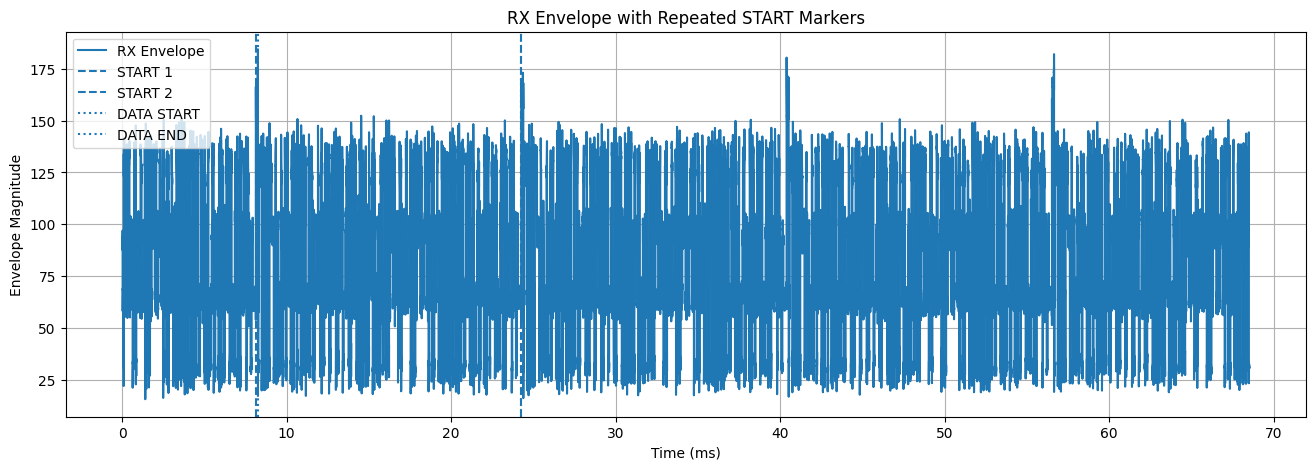

In [9]:
plt.figure(figsize=(16, 5))

time_axis = np.arange(len(rx_envelope)) / fs

plt.plot(
    time_axis * 1e3,
    rx_envelope,
    label="RX Envelope"
)

plt.axvline(
    start1 / fs * 1e3,
    linestyle="--",
    label="START 1"
)

plt.axvline(
    start2 / fs * 1e3,
    linestyle="--",
    label="START 2"
)

plt.axvline(
    data_start / fs * 1e3,
    linestyle=":",
    label="DATA START"
)

plt.axvline(
    data_end / fs * 1e3,
    linestyle=":",
    label="DATA END"
)

plt.xlabel("Time (ms)")
plt.ylabel("Envelope Magnitude")
plt.title("RX Envelope with Repeated START Markers")
plt.grid(True)
plt.legend()
plt.show()

## Task 8: Measure the Bit Error Rate

Compare your recovered bits against the transmitted bits, position by position, for the single
frame you just captured. Don't capture additional frames and pool them together — a single
frame's error count already tells you what you need, and averaging across frames would hide
the burst-to-burst variability you're trying to observe.

Count how many bit positions disagree, and report that count as a fraction of the total number
of bits in the frame.

In [10]:
n_bit_errors = np.sum(rx_bits != tx_bits)   # TODO: count positions where rx_bits and tx_bits differ
ber = n_bit_errors / n_bits             # TODO: n_bit_errors as a fraction of n_bits

print(f"Bit errors: {n_bit_errors} / {n_bits}  (BER = {ber:.2e})")

Bit errors: 0 / 1000  (BER = 0.00e+00)


## Task 9: Bit Error Rate versus Transmit Gain

Repeat the transmit-capture-detect-score procedure from Tasks 3 through 8 at several different
transmit hardware gain settings, holding the receive gain fixed throughout, to see how the bit
error rate responds as the received signal strength changes relative to a fixed noise floor.

Wrap the full procedure in a function, so you can call it once per gain setting without
retyping it. Sweep a handful of gain values spanning from clearly error-free down to clearly
unusable. Plot the resulting bit error rate on a logarithmic vertical axis against the gain
values on a linear horizontal axis.

TX Gain =  -80 dB | START1 =   328 | START2 = 13242 | RX levels = [0.18 0.36 0.54 0.72] | Errors =  493/1000 | BER = 4.930e-01
TX bits: [1 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1]
RX bits: [1 0 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 0]


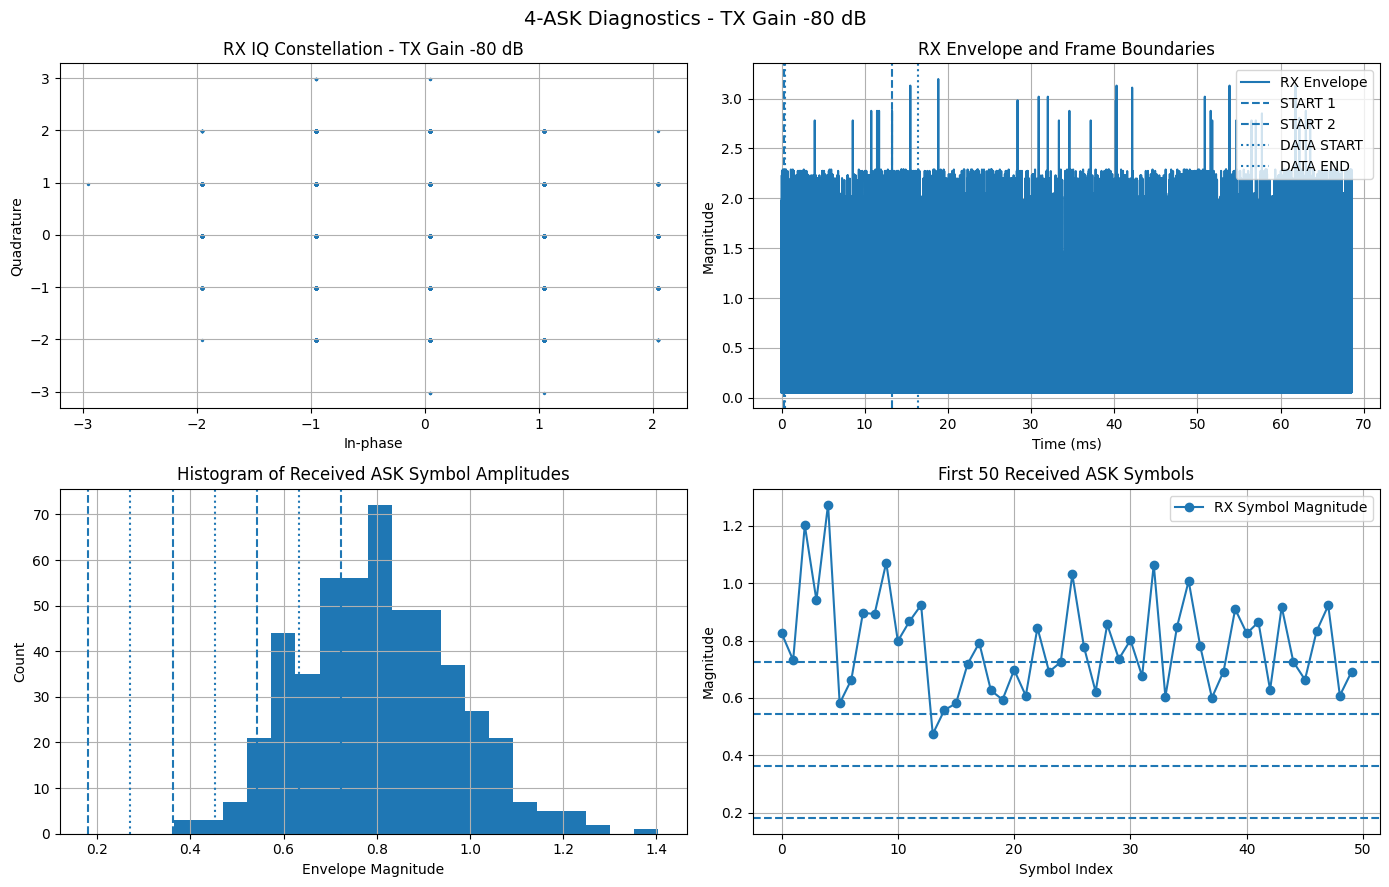

TX Gain =  -75 dB | START1 =  1194 | START2 = 14736 | RX levels = [0.19 0.38 0.57 0.76] | Errors =  486/1000 | BER = 4.860e-01
TX bits: [0 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0]
RX bits: [1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]


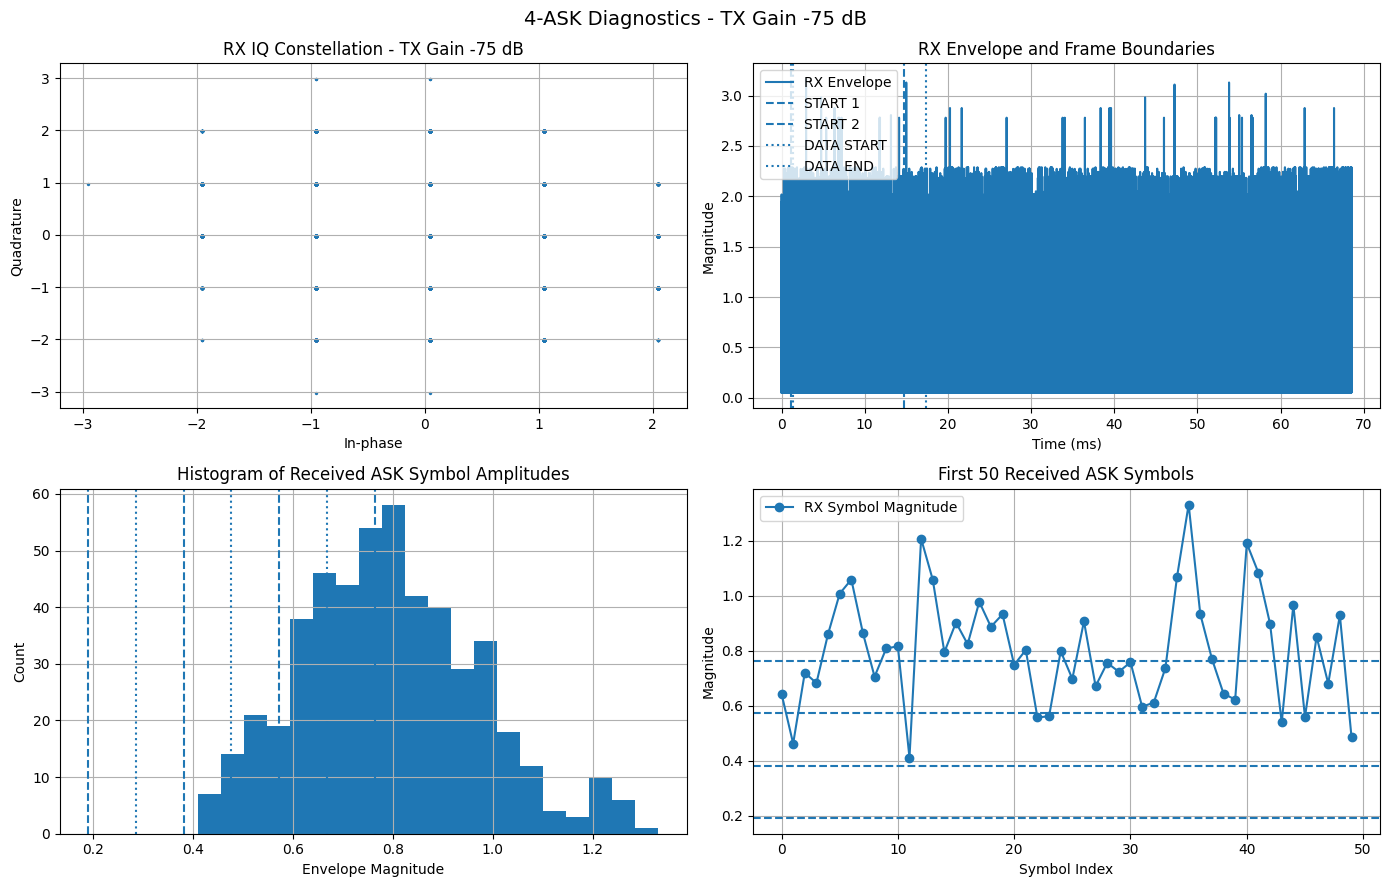

TX Gain =  -70 dB | START1 =   196 | START2 = 25860 | RX levels = [0.21 0.41 0.62 0.83] | Errors =  504/1000 | BER = 5.040e-01
TX bits: [1 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 1]
RX bits: [1 1 1 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 0]


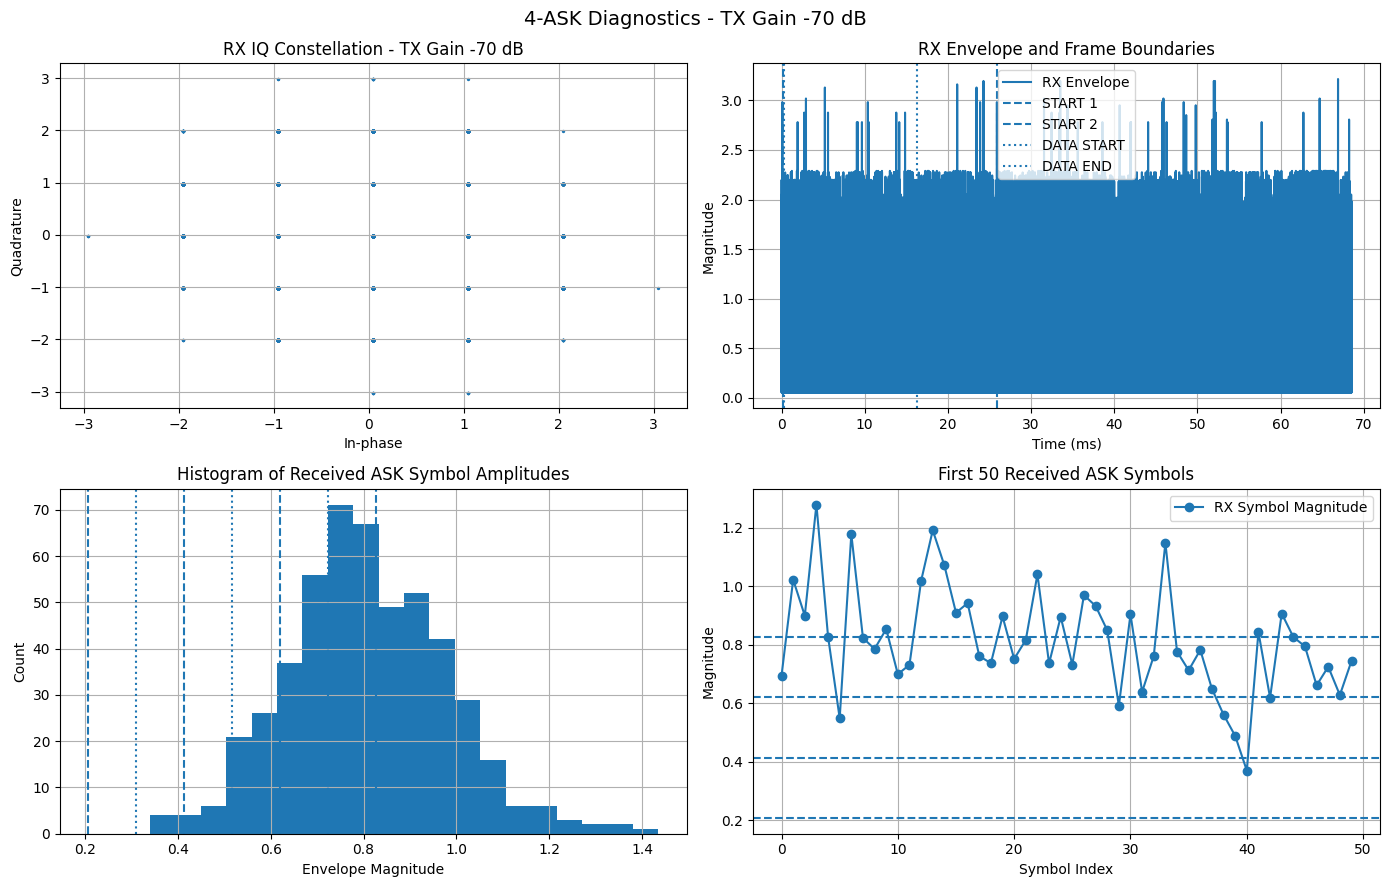

TX Gain =  -65 dB | START1 =  1924 | START2 = 15869 | RX levels = [0.24 0.47 0.71 0.95] | Errors =  484/1000 | BER = 4.840e-01
TX bits: [1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 1 1]
RX bits: [1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1]


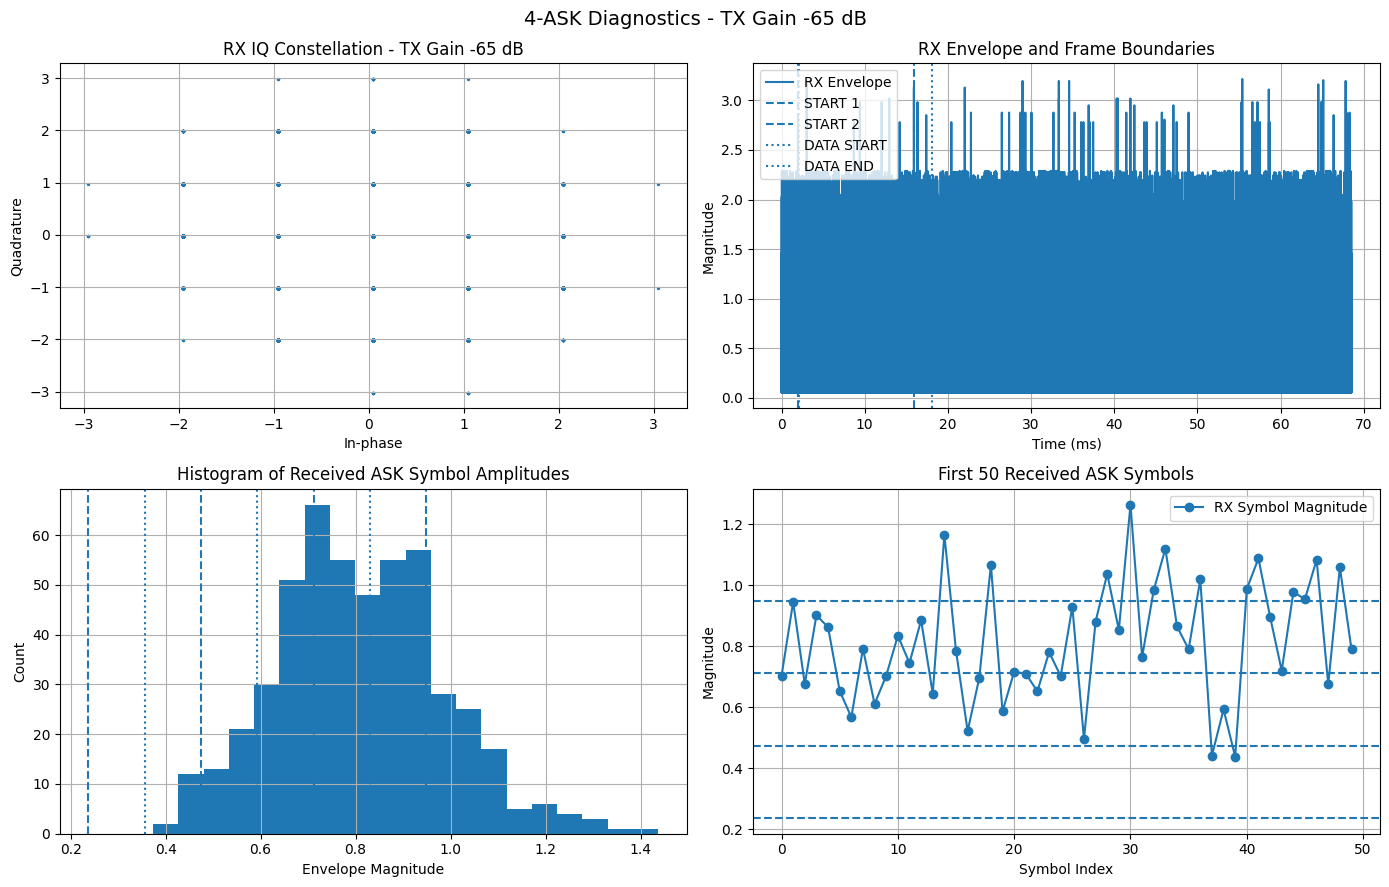

TX Gain =  -60 dB | START1 =   361 | START2 = 13276 | RX levels = [0.15 0.31 0.46 0.61] | Errors =  483/1000 | BER = 4.830e-01
TX bits: [1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1]
RX bits: [1 0 1 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0]


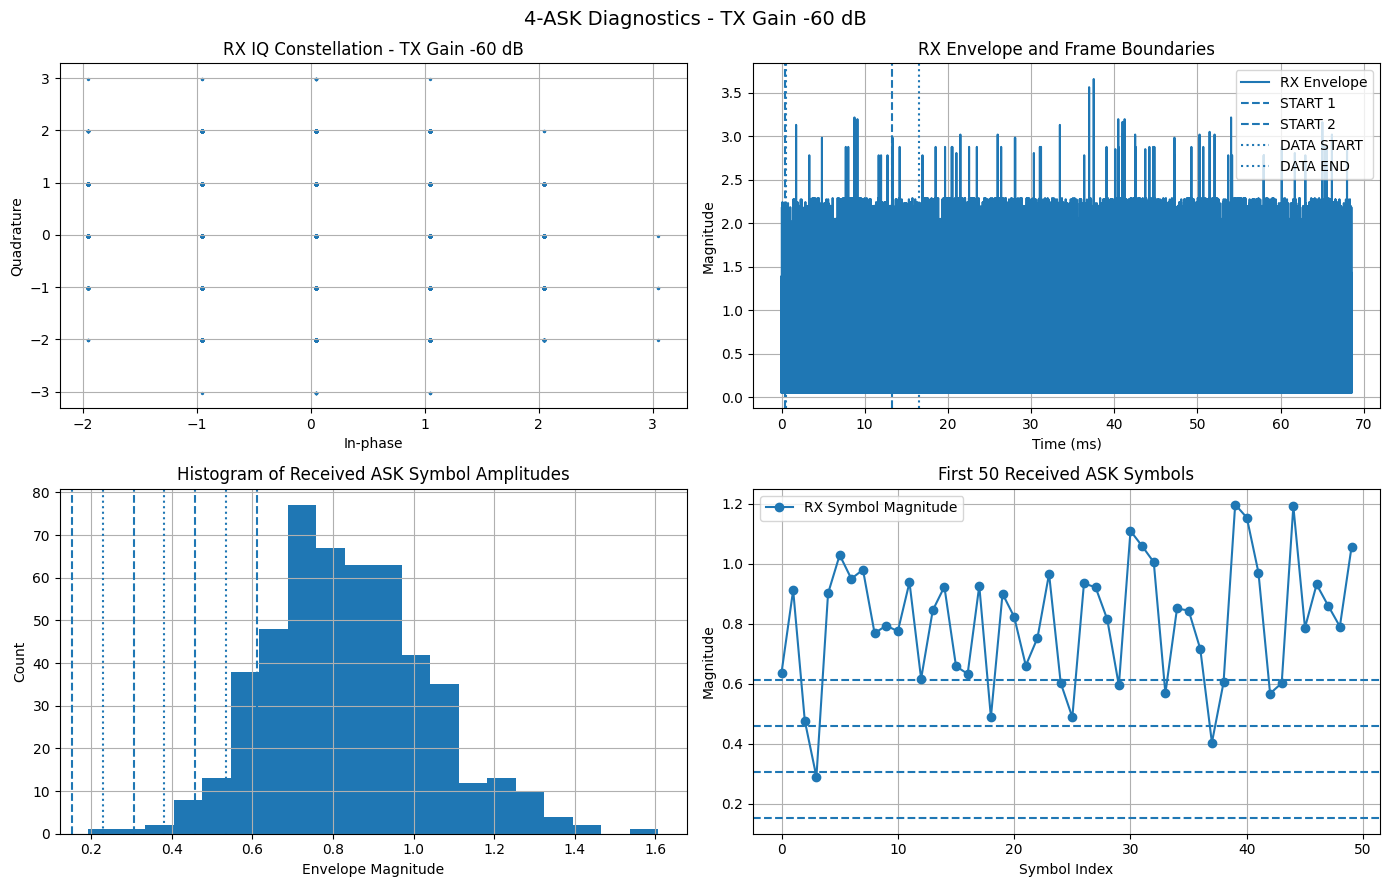

TX Gain =  -55 dB | START1 =   494 | START2 = 13802 | RX levels = [0.29 0.57 0.86 1.15] | Errors =  484/1000 | BER = 4.840e-01
TX bits: [0 1 0 1 0 1 0 1 1 0 0 1 0 1 0 0 1 0 0 1]
RX bits: [0 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0]


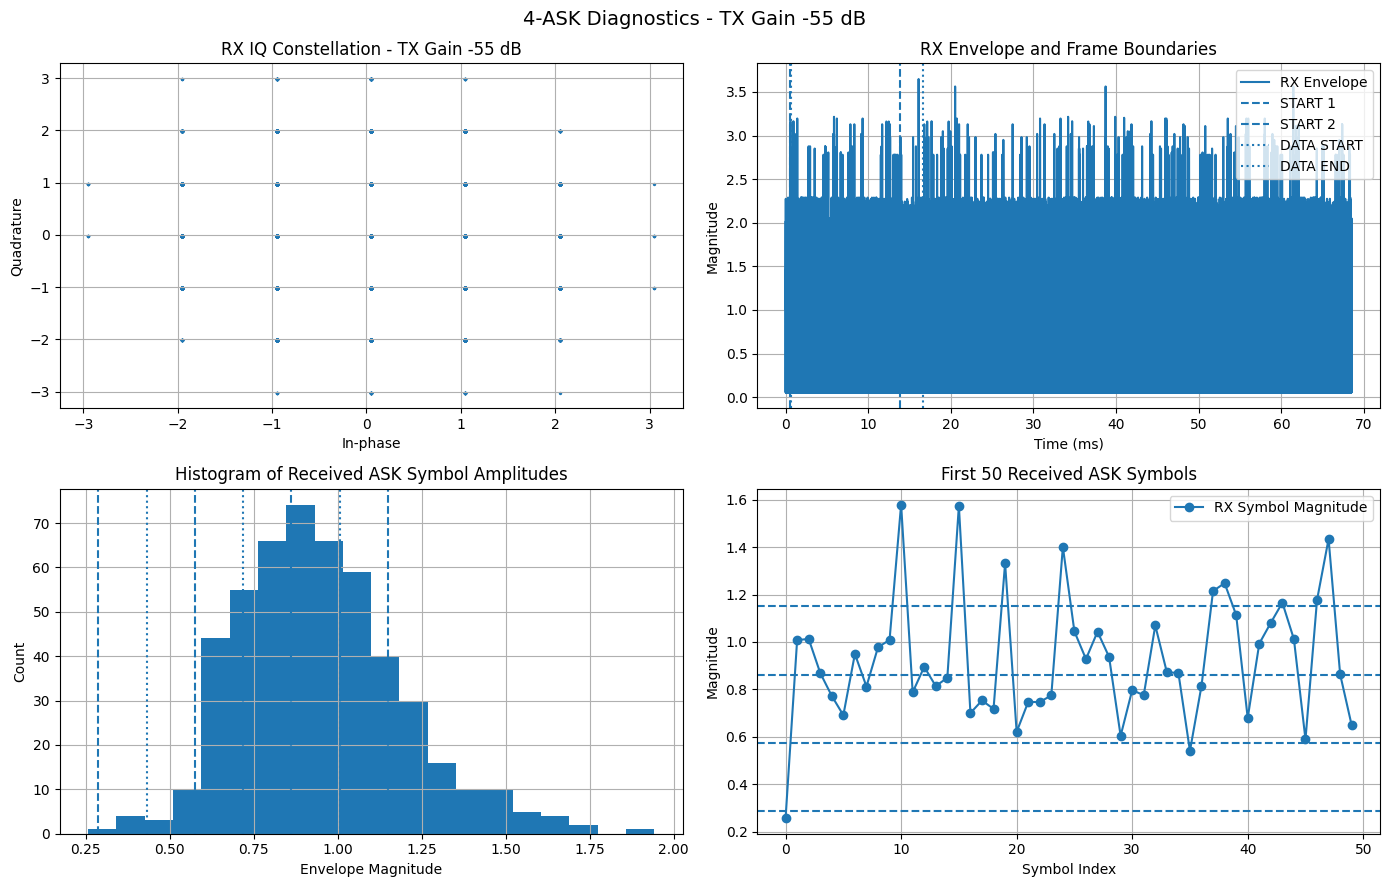

TX Gain =  -50 dB | START1 =  5755 | START2 = 21866 | RX levels = [0.41 0.81 1.22 1.63] | Errors =  414/1000 | BER = 4.140e-01
TX bits: [1 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0]
RX bits: [1 1 1 1 0 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1]


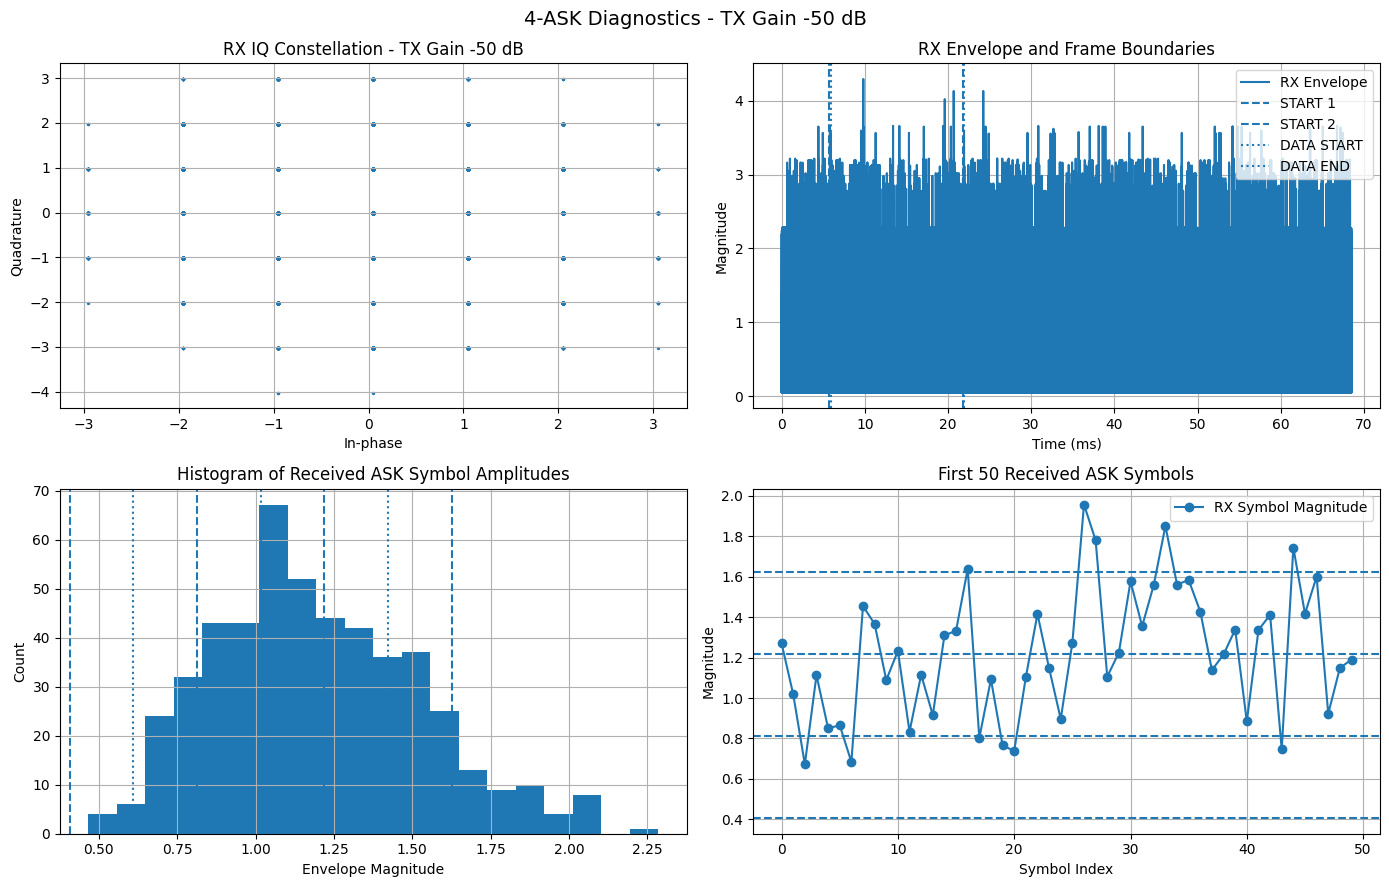

TX Gain =  -45 dB | START1 =  8530 | START2 = 24654 | RX levels = [0.49 0.97 1.46 1.94] | Errors =  259/1000 | BER = 2.590e-01
TX bits: [1 1 1 1 1 0 1 1 1 1 0 1 0 0 1 0 1 0 0 1]
RX bits: [1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1]


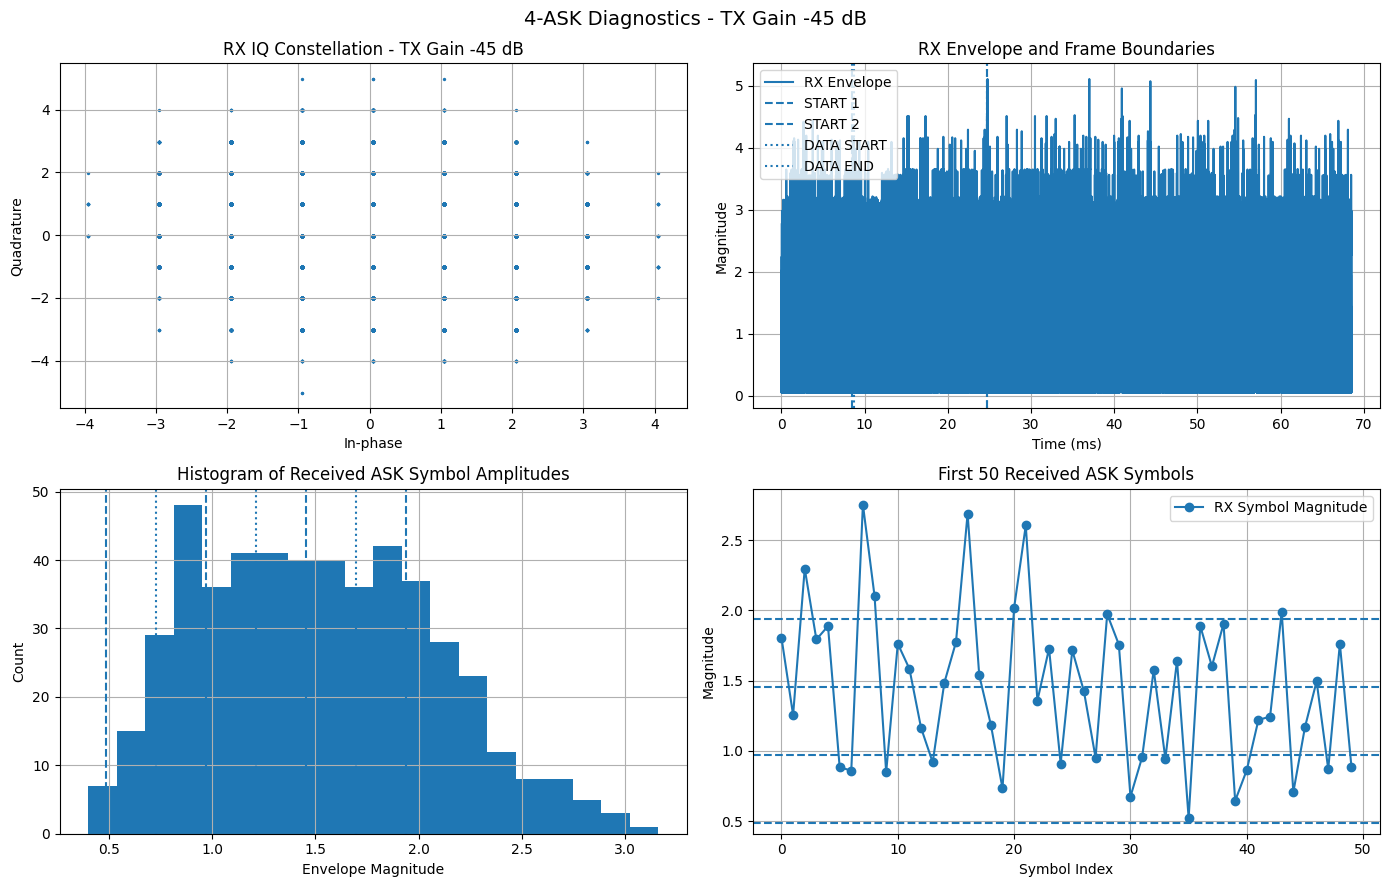

TX Gain =  -40 dB | START1 =  8465 | START2 = 24593 | RX levels = [0.98 1.95 2.93 3.91] | Errors =  125/1000 | BER = 1.250e-01
TX bits: [1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0]
RX bits: [1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0]


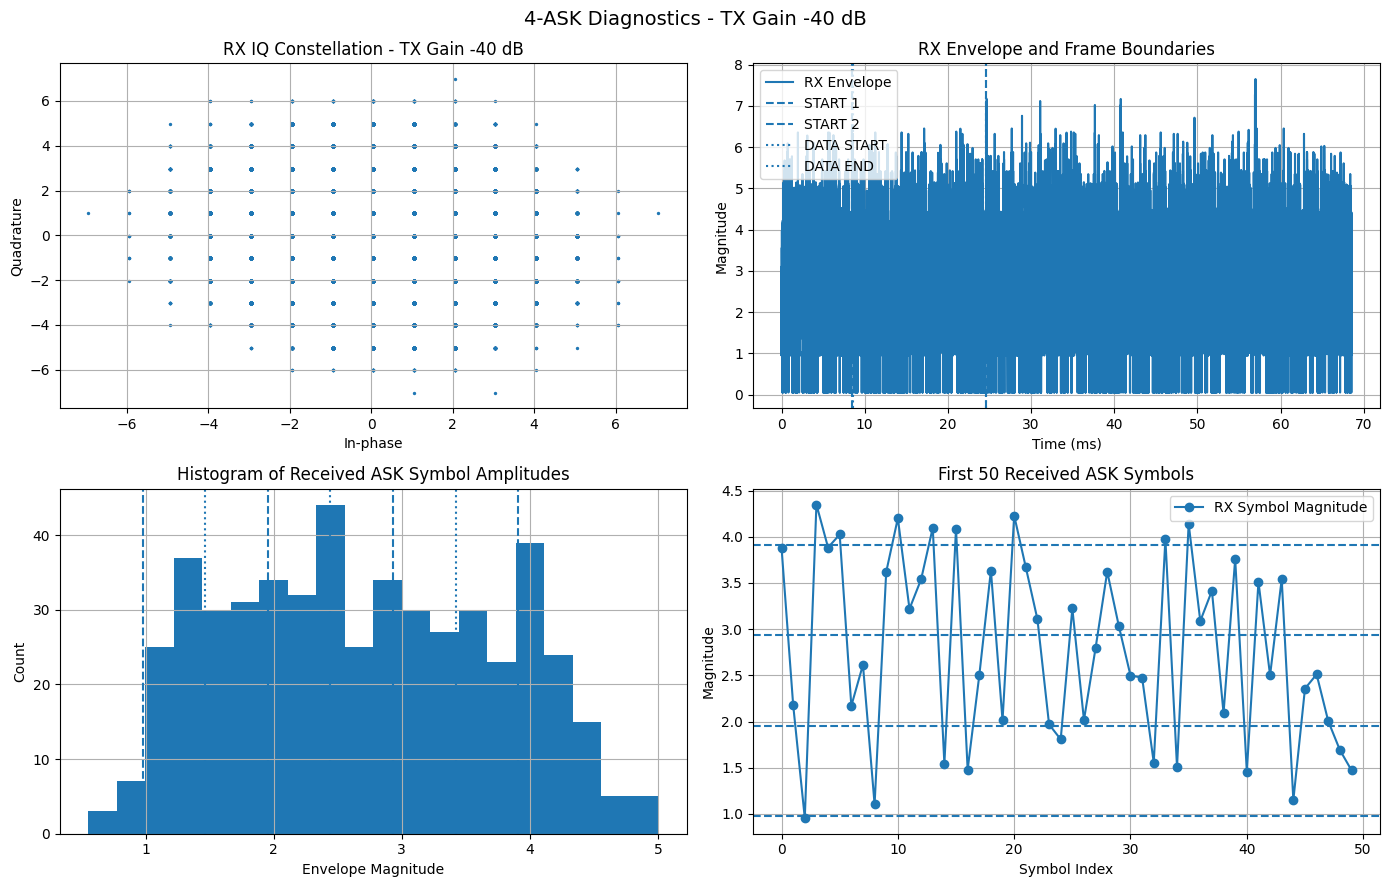

TX Gain =  -35 dB | START1 =  7966 | START2 = 24094 | RX levels = [1.7  3.41 5.11 6.81] | Errors =   28/1000 | BER = 2.800e-02
TX bits: [1 1 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 0 0 1]
RX bits: [1 1 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 0 0 1]


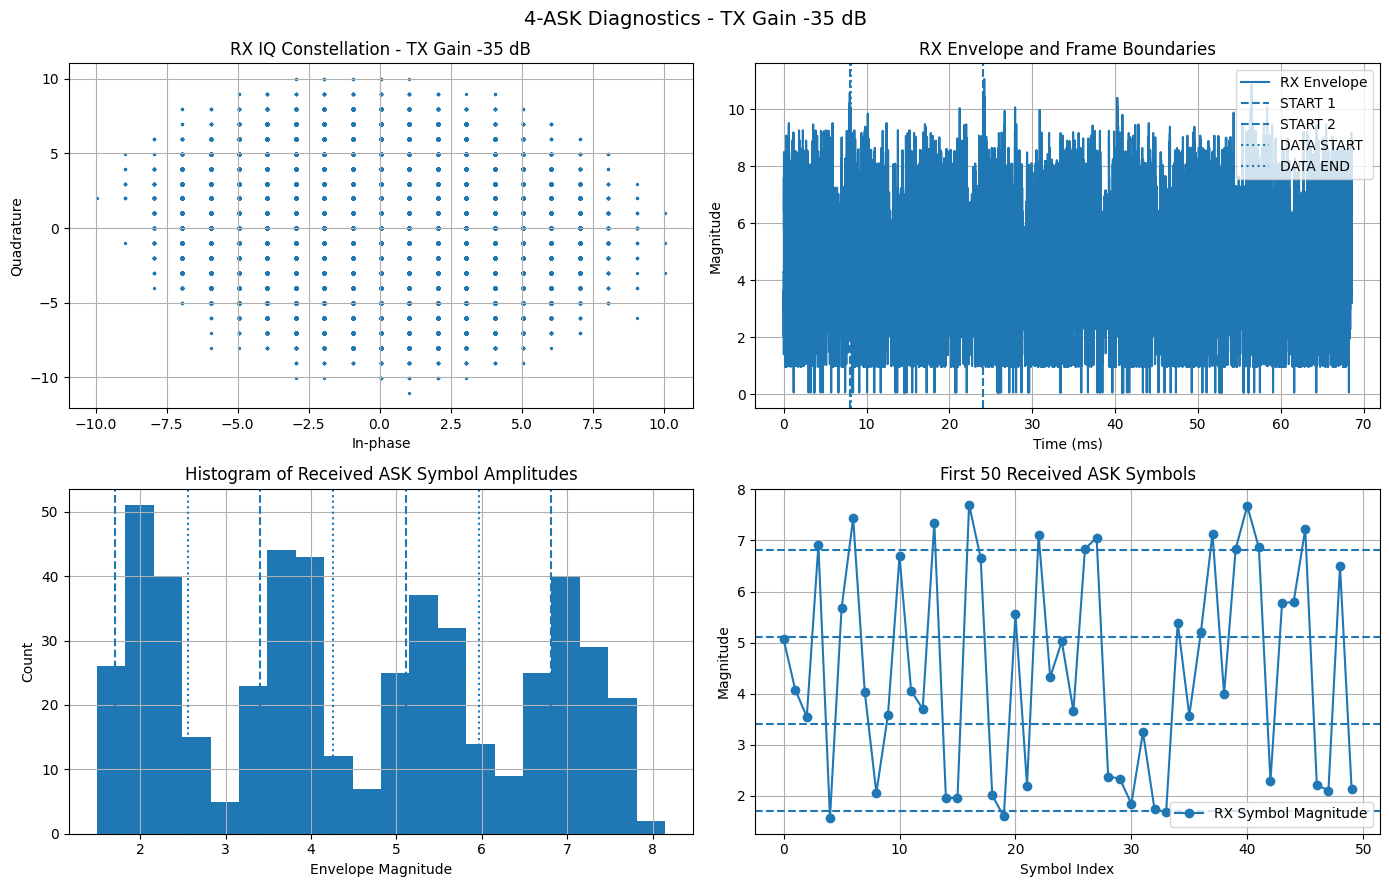

TX Gain =  -30 dB | START1 =  7851 | START2 = 23979 | RX levels = [ 3.12  6.24  9.36 12.47] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1]
RX bits: [0 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1]


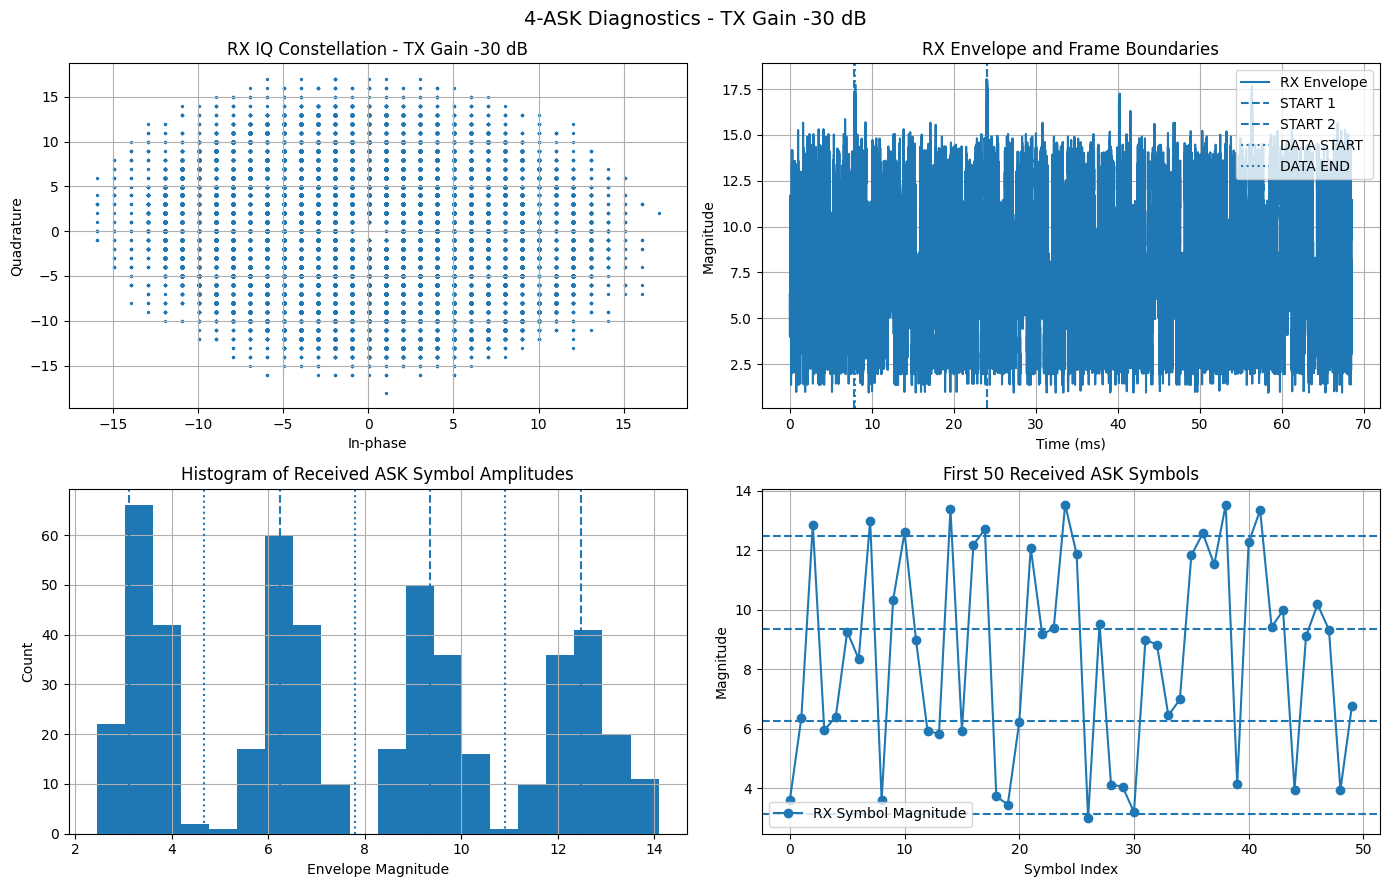

TX Gain =  -25 dB | START1 =  8234 | START2 = 24362 | RX levels = [ 5.69 11.39 17.08 22.78] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0]
RX bits: [1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0]


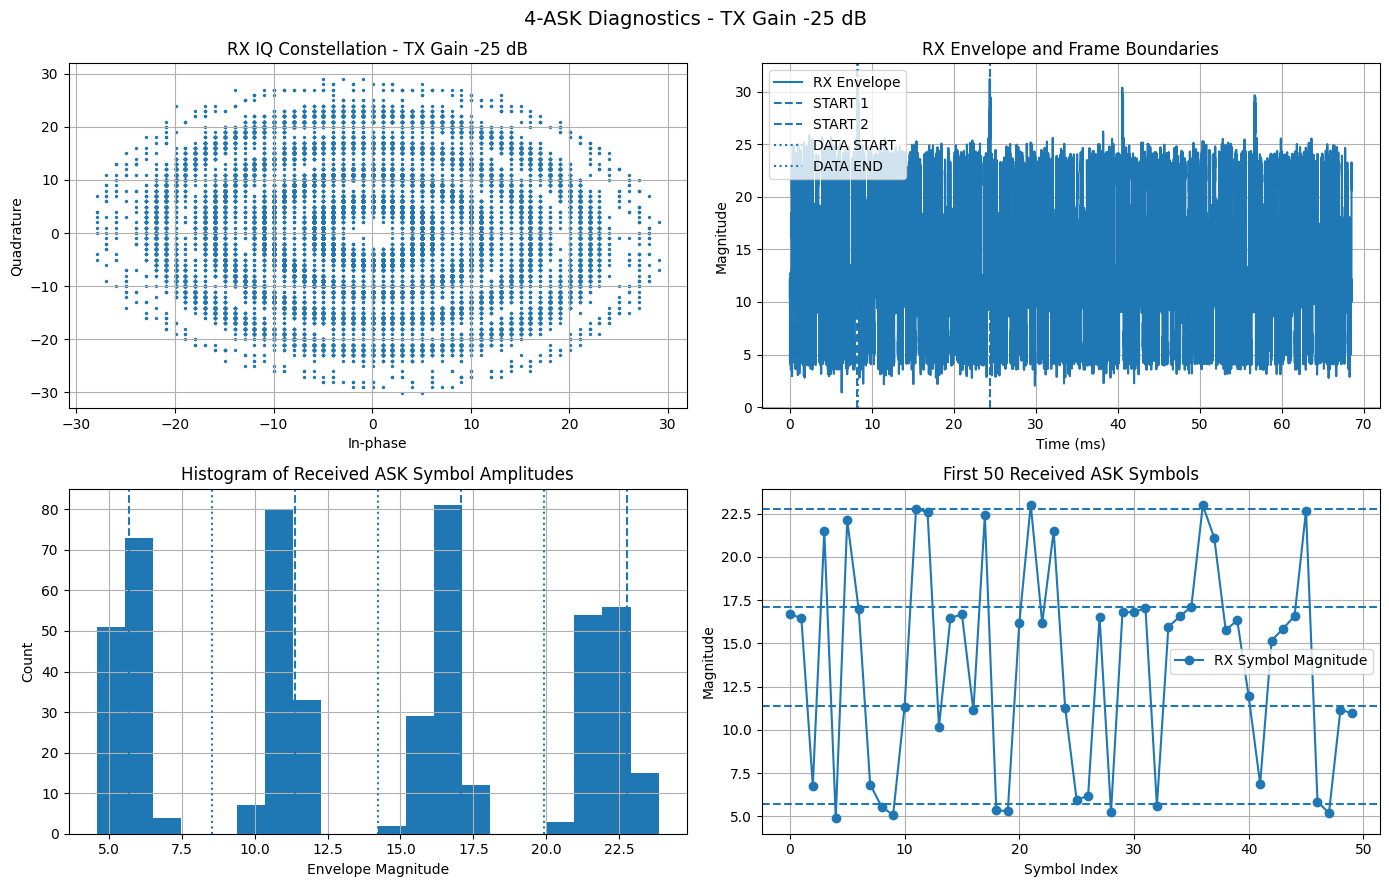

TX Gain =  -20 dB | START1 =  8091 | START2 = 24219 | RX levels = [10.03 20.07 30.1  40.14] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [0 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0]
RX bits: [0 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 0]


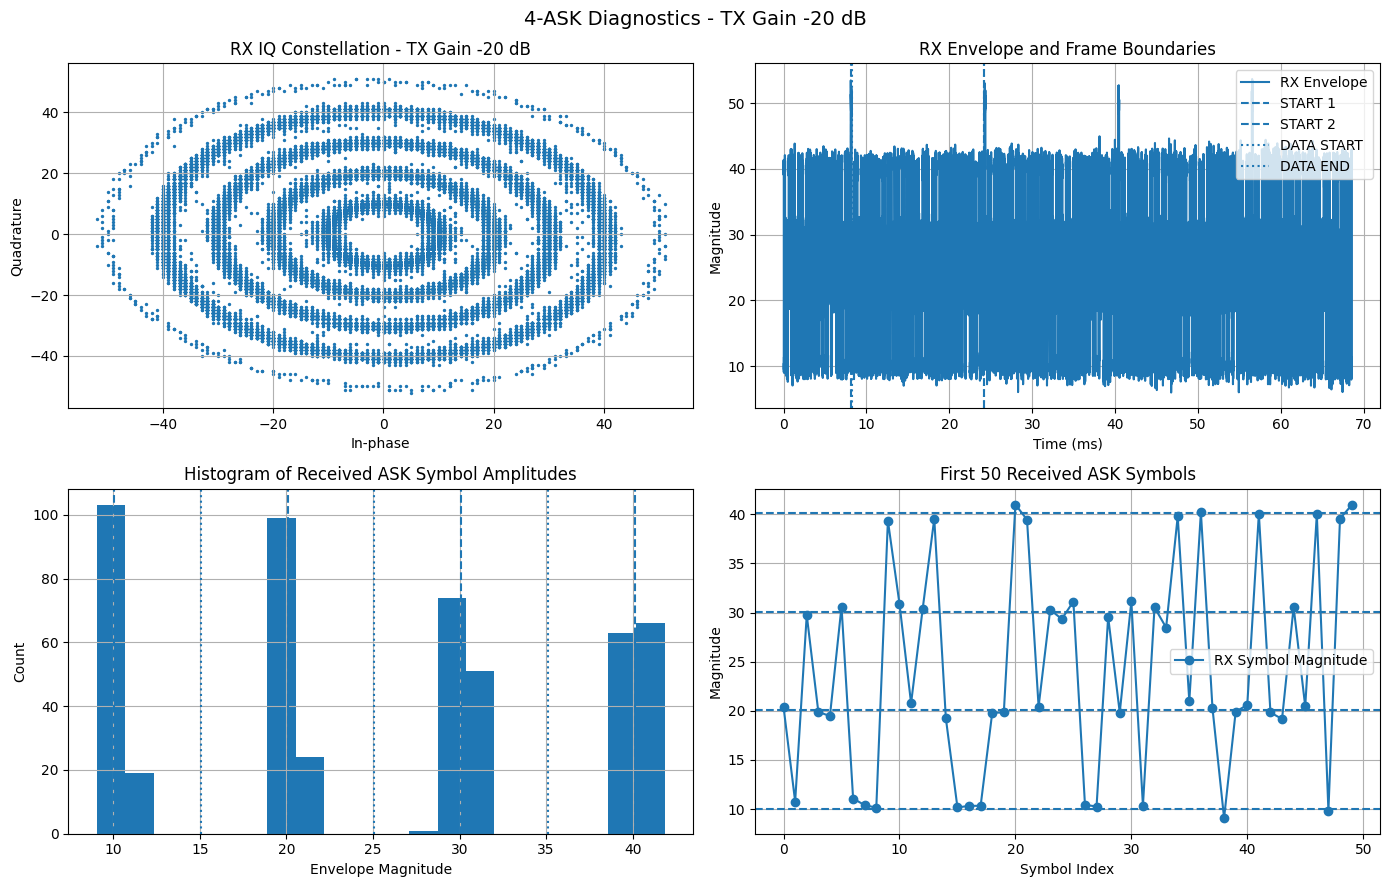

TX Gain =  -15 dB | START1 =  7922 | START2 = 24050 | RX levels = [19.35 38.71 58.06 77.41] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [0 1 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0]
RX bits: [0 1 1 0 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0]


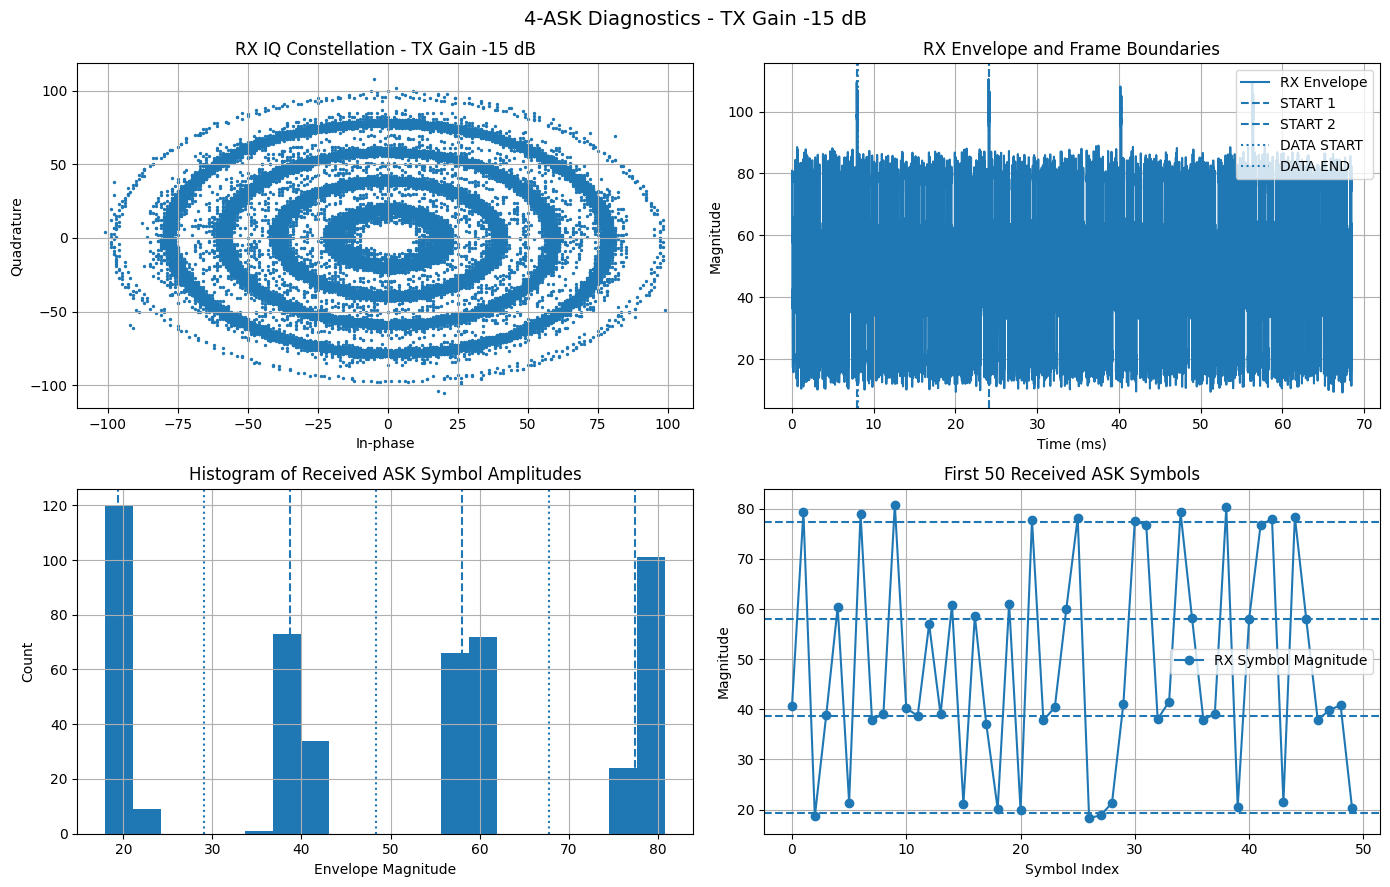

TX Gain =  -10 dB | START1 =  8595 | START2 = 24723 | RX levels = [ 33.05  66.1   99.16 132.21] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0]
RX bits: [0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 0]


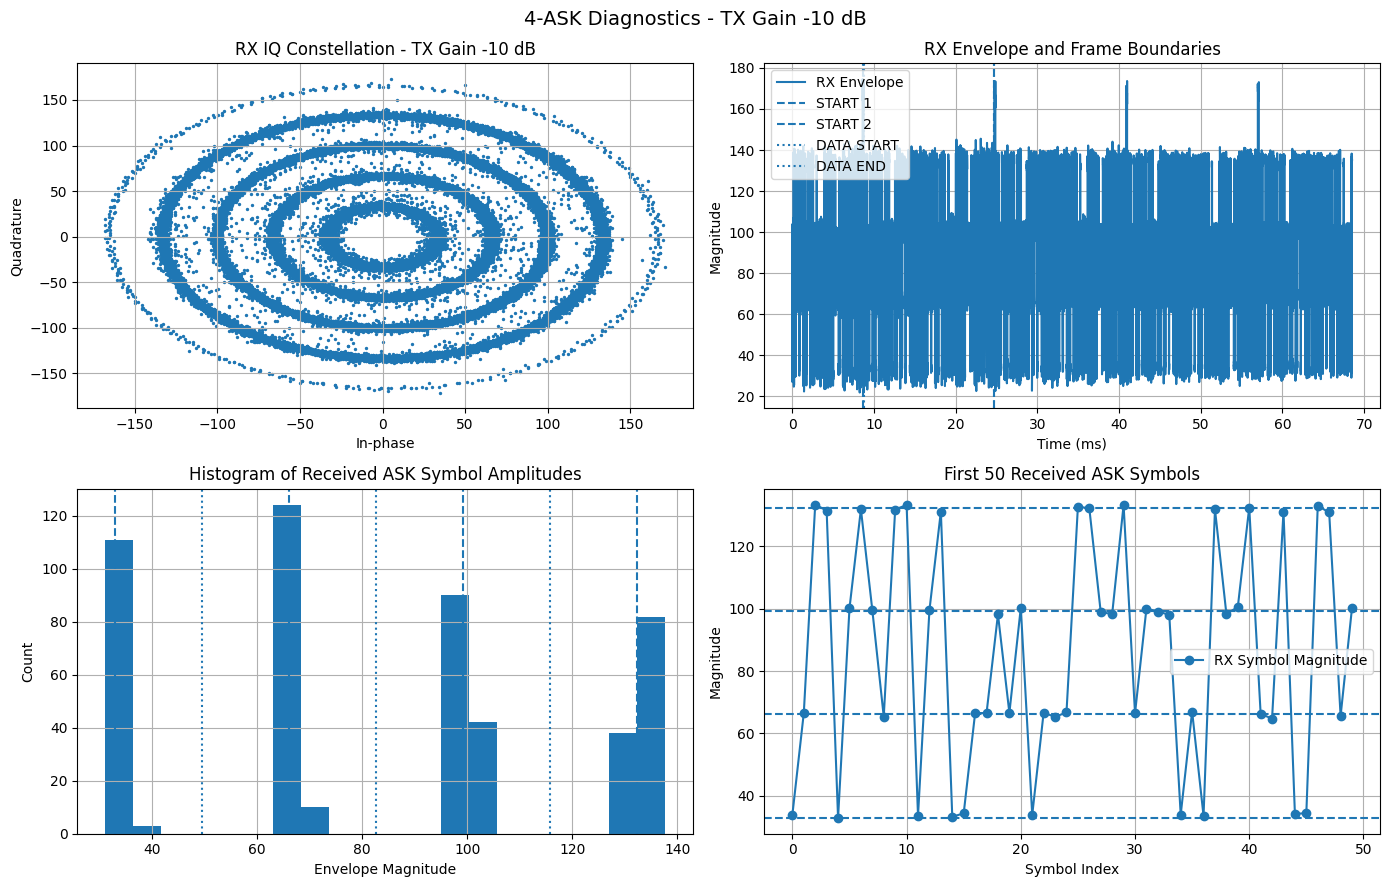

TX Gain =   -5 dB | START1 =  8122 | START2 = 24250 | RX levels = [ 54.34 108.68 163.02 217.36] | Errors =    0/1000 | BER = 0.000e+00
TX bits: [1 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1]
RX bits: [1 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1]


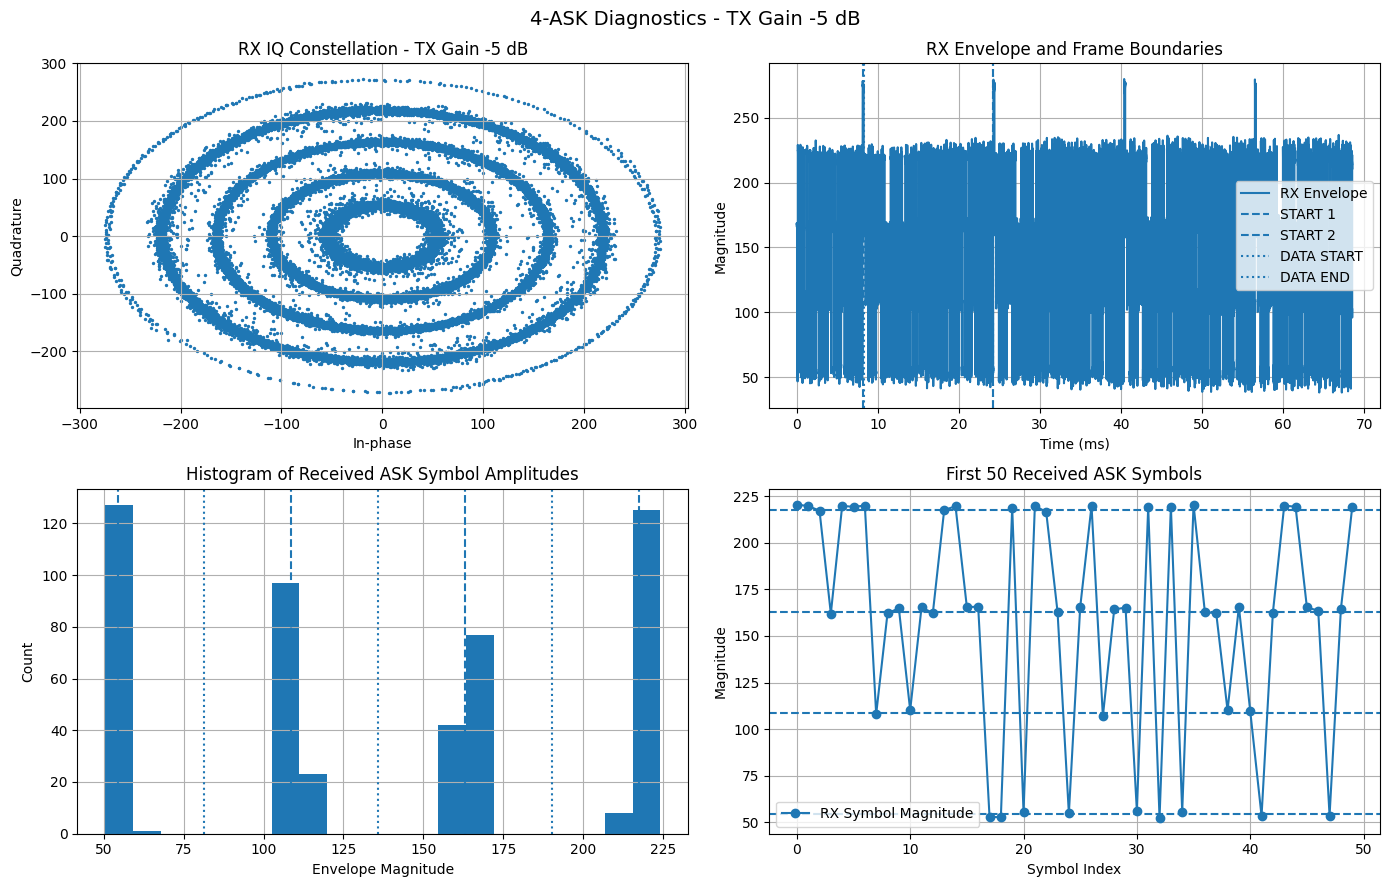


FINAL BER RESULTS
TX Gain =  -80 dB    BER = 4.930e-01
TX Gain =  -75 dB    BER = 4.860e-01
TX Gain =  -70 dB    BER = 5.040e-01
TX Gain =  -65 dB    BER = 4.840e-01
TX Gain =  -60 dB    BER = 4.830e-01
TX Gain =  -55 dB    BER = 4.840e-01
TX Gain =  -50 dB    BER = 4.140e-01
TX Gain =  -45 dB    BER = 2.590e-01
TX Gain =  -40 dB    BER = 1.250e-01
TX Gain =  -35 dB    BER = 2.800e-02
TX Gain =  -30 dB    BER = 0.000e+00
TX Gain =  -25 dB    BER = 0.000e+00
TX Gain =  -20 dB    BER = 0.000e+00
TX Gain =  -15 dB    BER = 0.000e+00
TX Gain =  -10 dB    BER = 0.000e+00
TX Gain =   -5 dB    BER = 0.000e+00


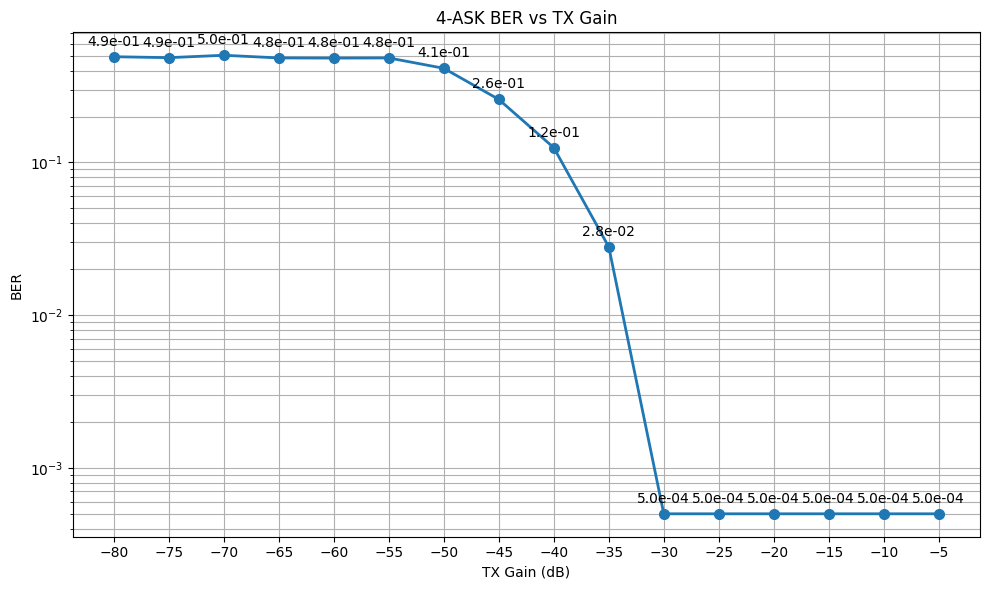

In [11]:
def measure_ber_at_gain(tx_gain_db, n_bits=n_bits):
    '''
    TODO: implement the full Task 3-8 procedure for the given transmit gain and return the
    resulting BER. Reuse ASK4_LEVELS, ASK4_GRAY, sps, and dc_offset from earlier in the
    notebook; only the transmit gain changes between calls.
    '''

    # =========================================================
    # Set TX gain
    # =========================================================
    tx_sdr.tx_hardwaregain_chan0 = tx_gain_db

    # =========================================================
    # TASK 3: Generate random bits and 4-ASK symbols
    # =========================================================

    tx_bits_local = np.random.randint(
        0, 2, n_bits
    )            # TODO: random array of n_bits bits (0s and 1s)

    tx_symbols_local = np.array([
        np.where(
            np.all(ASK4_GRAY == pair, axis=1)
        )[0][0]
        for pair in tx_bits_local.reshape(-1, 2)
    ])          # TODO: group tx_bits into 2-bit symbols (integer values 0-3)

    tx_amplitudes_local = ASK4_LEVELS[
        tx_symbols_local
    ]       # TODO: look up each symbol's amplitude from Task 2's mapping

    # =========================================================
    # START MARKER + DATA
    # =========================================================

    start_symbols_local = np.ones(4)

    start_waveform_local = np.repeat(
        start_symbols_local,
        sps
    )

    data_waveform_local = np.repeat(
        tx_amplitudes_local,
        sps
    )

    tx_waveform_local = (
        np.concatenate([
            start_waveform_local,
            data_waveform_local
        ]) * tx_scale
    ).astype(np.complex64)          # TODO: hold each amplitude for sps samples to build the
                                   #       rectangular pulse train (complex64)

    # =========================================================
    # TASK 4: Transmit and capture
    # =========================================================

    # Capture several repeated frames
    rx_sdr.rx_buffer_size = (
        4 * len(tx_waveform_local) + 5000
    )   # TODO: size the buffer to comfortably hold one frame

    tx_sdr.tx_destroy_buffer()

    tx_sdr.tx_cyclic_buffer = True
    tx_sdr.tx(tx_waveform_local)

    time.sleep(0.5)

    rx_raw_local = rx_sdr.rx()           # TODO: capture from rx_sdr

    tx_sdr.tx_destroy_buffer()
    rx_sdr.rx_destroy_buffer()

    # Remove initial transient and DC offset
    rx_calibrated_local = (
        rx_raw_local[1000:] - dc_offset
    )     # TODO: discard the initial transient, then apply the Task 1
          #       DC-offset calibration to what remains

    # =========================================================
    # TASK 5: Envelope detection
    # =========================================================

    rx_envelope_local = np.abs(
        rx_calibrated_local
    )          # TODO: magnitude of every sample in rx_calibrated

    # =========================================================
    # Frame parameters
    # =========================================================

    start_symbol_count = 4
    start_length = start_symbol_count * sps

    n_data_symbols_local = n_bits // 2
    data_length = n_data_symbols_local * sps

    frame_length = start_length + data_length

    # =========================================================
    # FIND REPEATED START PEAKS
    # =========================================================

    smooth = np.convolve(
        rx_envelope_local,
        np.ones(start_length) / start_length,
        mode="valid"
    )

    from scipy.signal import find_peaks

    peaks, _ = find_peaks(
        smooth,
        distance=int(0.8 * frame_length),
        prominence=0.1 * np.max(smooth)
    )

    # Need two START peaks so that one complete frame
    # can be taken between them.
    if len(peaks) < 2:

        print(
            f"TX Gain = {tx_gain_db:>4} dB | "
            f"START peaks not found | BER = 1.000e+00"
        )

        # Still show the received signal so the failure can be inspected
        fig, ax = plt.subplots(2, 2, figsize=(14, 9))

        # 1. IQ constellation
        ax[0, 0].scatter(
            rx_calibrated_local.real,
            rx_calibrated_local.imag,
            s=2
        )
        ax[0, 0].set_title(f"RX IQ Constellation ({tx_gain_db} dB)")
        ax[0, 0].set_xlabel("In-phase")
        ax[0, 0].set_ylabel("Quadrature")
        ax[0, 0].grid(True)

        # 2. Envelope
        time_axis = np.arange(len(rx_envelope_local)) / fs

        ax[0, 1].plot(
            time_axis * 1e3,
            rx_envelope_local
        )
        ax[0, 1].set_title("RX Envelope vs Time")
        ax[0, 1].set_xlabel("Time (ms)")
        ax[0, 1].set_ylabel("Magnitude")
        ax[0, 1].grid(True)

        # 3. Smoothed envelope
        ax[1, 0].plot(
            np.arange(len(smooth)) / fs * 1e3,
            smooth
        )
        ax[1, 0].set_title("START Detection Signal")
        ax[1, 0].set_xlabel("Time (ms)")
        ax[1, 0].set_ylabel("Moving Average")
        ax[1, 0].grid(True)

        # 4. Histogram
        ax[1, 1].hist(
            rx_envelope_local,
            bins=50
        )
        ax[1, 1].set_title("RX Magnitude Histogram")
        ax[1, 1].set_xlabel("Magnitude")
        ax[1, 1].set_ylabel("Count")
        ax[1, 1].grid(True)

        plt.tight_layout()
        plt.show()

        return 1.0

    # First two repeated START markers
    start1 = peaks[0]
    start2 = peaks[1]

    # =========================================================
    # DATA BETWEEN START 1 AND START 2
    # =========================================================

    data_start = start1 + start_length
    data_end = data_start + data_length

    # Make sure complete data frame exists
    if data_end > len(rx_envelope_local):

        print(
            f"TX Gain = {tx_gain_db:>4} dB | "
            f"Not enough RX samples | BER = 1.000e+00"
        )

        return 1.0

    data_samples_local = rx_envelope_local[
        data_start:data_end
    ]

    # =========================================================
    # Estimate received ASK levels
    # =========================================================

    start_region_local = rx_envelope_local[
        start1 + sps :
        start1 + start_length - sps
    ]

    if len(start_region_local) == 0:
        return 1.0

    rx_full_scale_local = np.mean(
        start_region_local
    )

    # Received versions of:
    # 0.2, 0.4, 0.6, 0.8
    rx_levels_local = (
        ASK4_LEVELS * rx_full_scale_local
    )

    # Midpoints between ASK levels
    thresholds_local = (
        rx_levels_local[:-1] +
        rx_levels_local[1:]
    ) / 2

    # =========================================================
    # TASK 7: Decode symbols
    # =========================================================

    # Average middle half of each symbol
    rx_center_samples_local = np.array([
        np.mean(
            data_samples_local[
                i * sps + sps // 4 :
                i * sps + 3 * sps // 4
            ]
        )
        for i in range(n_data_symbols_local)
    ])

    # Decode using midpoint thresholds
    rx_symbols_local = np.digitize(
        rx_center_samples_local,
        thresholds_local
    )

    rx_symbols_local = np.clip(
        rx_symbols_local,
        0,
        3
    )

    # Map symbols back to Gray-coded bits
    rx_bits_local = ASK4_GRAY[
        rx_symbols_local
    ].flatten()

    # =========================================================
    # TASK 8: BER
    # =========================================================

    n_bit_errors_local = np.sum(
        rx_bits_local != tx_bits_local
    )

    ber_local = (
        n_bit_errors_local / n_bits
    )

    # =========================================================
    # PRINT RESULT
    # =========================================================

    print(
        f"TX Gain = {tx_gain_db:>4} dB | "
        f"START1 = {start1:>5} | "
        f"START2 = {start2:>5} | "
        f"RX levels = {np.round(rx_levels_local, 2)} | "
        f"Errors = {n_bit_errors_local:>4}/{n_bits} | "
        f"BER = {ber_local:.3e}"
    )

    print("TX bits:", tx_bits_local[:20])
    print("RX bits:", rx_bits_local[:20])

    # =========================================================
    # PLOTS FOR THIS TX GAIN
    # =========================================================

    fig, ax = plt.subplots(
        2, 2,
        figsize=(14, 9)
    )

    # ---------------------------------------------------------
    # 1. RX IQ constellation
    # ---------------------------------------------------------

    ax[0, 0].scatter(
        rx_calibrated_local.real,
        rx_calibrated_local.imag,
        s=2
    )

    ax[0, 0].set_title(
        f"RX IQ Constellation - TX Gain {tx_gain_db} dB"
    )
    ax[0, 0].set_xlabel("In-phase")
    ax[0, 0].set_ylabel("Quadrature")
    ax[0, 0].grid(True)

    # ---------------------------------------------------------
    # 2. RX envelope + START markers + DATA region
    # ---------------------------------------------------------

    time_axis = np.arange(
        len(rx_envelope_local)
    ) / fs

    ax[0, 1].plot(
        time_axis * 1e3,
        rx_envelope_local,
        label="RX Envelope"
    )

    ax[0, 1].axvline(
        start1 / fs * 1e3,
        linestyle="--",
        label="START 1"
    )

    ax[0, 1].axvline(
        start2 / fs * 1e3,
        linestyle="--",
        label="START 2"
    )

    ax[0, 1].axvline(
        data_start / fs * 1e3,
        linestyle=":",
        label="DATA START"
    )

    ax[0, 1].axvline(
        data_end / fs * 1e3,
        linestyle=":",
        label="DATA END"
    )

    ax[0, 1].set_title(
        "RX Envelope and Frame Boundaries"
    )
    ax[0, 1].set_xlabel("Time (ms)")
    ax[0, 1].set_ylabel("Magnitude")
    ax[0, 1].grid(True)
    ax[0, 1].legend()

    # ---------------------------------------------------------
    # 3. Histogram of received symbol amplitudes
    # ---------------------------------------------------------

    ax[1, 0].hist(
        rx_center_samples_local,
        bins=20
    )

    # Show ASK levels
    for level in rx_levels_local:
        ax[1, 0].axvline(
            level,
            linestyle="--"
        )

    # Show decision thresholds
    for threshold in thresholds_local:
        ax[1, 0].axvline(
            threshold,
            linestyle=":"
        )

    ax[1, 0].set_title(
        "Histogram of Received ASK Symbol Amplitudes"
    )
    ax[1, 0].set_xlabel("Envelope Magnitude")
    ax[1, 0].set_ylabel("Count")
    ax[1, 0].grid(True)

    # ---------------------------------------------------------
    # 4. Symbol values + ASK levels
    # ---------------------------------------------------------

    n_show = min(
        len(rx_center_samples_local),
        50
    )

    symbol_indices = np.arange(
        n_show
    )

    ax[1, 1].plot(
        symbol_indices,
        rx_center_samples_local[:n_show],
        "o-",
        label="RX Symbol Magnitude"
    )

    for level in rx_levels_local:
        ax[1, 1].axhline(
            level,
            linestyle="--"
        )

    ax[1, 1].set_title(
        "First 50 Received ASK Symbols"
    )
    ax[1, 1].set_xlabel("Symbol Index")
    ax[1, 1].set_ylabel("Magnitude")
    ax[1, 1].grid(True)
    ax[1, 1].legend()

    plt.suptitle(
        f"4-ASK Diagnostics - TX Gain {tx_gain_db} dB",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    return ber_local


# =============================================================
# TASK 9: BER versus TX gain
# =============================================================

tx_gain_sweep_db = [
    -80, -75, -70, -65, -60, -55, -50, -45,
    -40, -35, -30, -25, -20, -15, -10, -5
]   # TODO: a handful of TX gain settings to sweep


ber_results = [
    measure_ber_at_gain(g)
    for g in tx_gain_sweep_db
]          # TODO: measure_ber_at_gain(g) for each g in tx_gain_sweep_db


# =============================================================
# FINAL BER TABLE
# =============================================================

print("\n" + "=" * 45)
print("FINAL BER RESULTS")
print("=" * 45)

for gain, ber_value in zip(
    tx_gain_sweep_db,
    ber_results
):
    print(
        f"TX Gain = {gain:>4} dB    "
        f"BER = {ber_value:.3e}"
    )


# =============================================================
# FINAL BER PLOT
# =============================================================

ber_plot = np.array(
    ber_results,
    dtype=float
)

# Log scale cannot represent zero.
# This replacement is ONLY for plotting.
ber_plot_for_plot = ber_plot.copy()

ber_plot_for_plot[
    ber_plot_for_plot == 0
] = 0.5 / n_bits

plt.figure(figsize=(10, 6))

plt.semilogy(
    tx_gain_sweep_db,
    ber_plot_for_plot,
    "o-",
    linewidth=2,
    markersize=7
)   # TODO: plt.semilogy(...) of ber_results vs. tx_gain_sweep_db, axis labels, grid, title

# Label every point
for gain, ber_value in zip(
    tx_gain_sweep_db,
    ber_plot_for_plot
):
    plt.annotate(
        f"{ber_value:.1e}",
        (gain, ber_value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("TX Gain (dB)")
plt.ylabel("BER")
plt.title("4-ASK BER vs TX Gain")
plt.xticks(tx_gain_sweep_db)
plt.grid(True, which="both")

plt.tight_layout()
plt.show()

In [12]:
import pickle
import os

save_path = os.path.expanduser("~/Desktop/lab5_variables.pkl")

variables_to_save = {
    "sps": sps,
    "n_bits": n_bits,
    "tx_scale": tx_scale,
    "fs": fs,
    "fc": fc,
    "ASK4_LEVELS": ASK4_LEVELS,
    "ASK4_GRAY": ASK4_GRAY,
    "dc_offset": dc_offset,
    "tx_bits": tx_bits,
    "tx_symbols": tx_symbols,
    "tx_amplitudes": tx_amplitudes,
    "tx_waveform": tx_waveform,
    "rx_raw": rx_raw,
    "rx_calibrated": rx_calibrated,
    "rx_envelope": rx_envelope,
    "rx_center_samples": rx_center_samples,
    "rx_symbols": rx_symbols,
    "rx_bits": rx_bits,
    "n_bit_errors": n_bit_errors,
    "ber": ber,
    "tx_gain_sweep_db": tx_gain_sweep_db,
    "ber_results": ber_results
}

with open(save_path, "wb") as f:
    pickle.dump(variables_to_save, f)

print("Saved successfully to:")
print(save_path)

Saved successfully to:
/home/student/Desktop/lab5_variables.pkl


## Background

**DC offset and LO leakage.** A small amount of a receiver's own local-oscillator signal
routinely couples into its receive path, and analog mixers and amplifiers carry their own
small imbalances. Together these show up as a constant complex offset added to every sample,
independent of whatever signal is actually arriving over the air. It doesn't average away on
its own, and unless it's measured and removed, it biases the center of every constellation and
every amplitude measurement you take afterward.

**Why magnitude ignores phase rotation.** A complex sample can be written as an amplitude
multiplied by a unit-magnitude phase factor. When two independently clocked oscillators drift
relative to one another, that phase factor rotates steadily over time, tracing out a spiral in
the IQ plane. Taking the magnitude of the sample discards the phase factor entirely, leaving
only the amplitude behind. This is why a coherent receiver (one that reads off phase, or a
signal's exact IQ position) must actively track and undo that rotation before it can make
correct decisions, while a receiver based purely on magnitude is unaffected by it from the
start. The cost is that magnitude alone cannot distinguish anything encoded in phase — it
only works because 4-ASK put no information there in the first place.

**Nearest-level decision.** In additive noise that is symmetric around zero, the most likely
transmitted amplitude, given a noisy received value, is simply whichever ideal level that
value sits closest to. This is the same reasoning you've applied to constellation points in
two dimensions, just restricted to points on a single positive axis. It's the optimal rule
precisely when the noise distribution is symmetric and the levels are used equally often —
both true here.

**Rectangular pulses and single-sample detection.** Holding each amplitude constant for the
full symbol duration, rather than shaping it some other way, means a single sample from the
middle of that duration is already a reasonable estimate of the transmitted amplitude — the
signal isn't changing there. This is a much simpler stand-in for the kind of matched filtering
you'd use with a non-rectangular pulse, where you'd want to combine information from many
samples rather than rely on just one.

# Concept Used to decode 4 ASK

-> Because of frequency offset constellation points rotate instead of correcting it we use energy concept to decode ASk

-> From histrogram take peak of each and map it to respective bits value 

-> while decoding finding midpoints of energy of beside bits and before midpoint means its respective

-> i am using a start bit with highest power 1 with sps 32*4

-> here sps is 32 from it majority take as decoded bit

## Questions

1. Why does subtracting the DC offset measured in Task 1 matter for the histogram you produced
   in Task 6? Sketch, in words, what that histogram would look like if you skipped this step.

2. The raw IQ scatter in Task 6 traces out a rotating pattern, but the amplitude histogram
   built from the same samples still shows four clean levels. In your own words, explain why
   the rotation doesn't interfere with the decision made in Task 7.

3. Suppose you doubled `sps` while keeping the total number of transmitted bits the same.
   Would you expect the bit error rate at a fixed transmit gain to improve, get worse, or stay
   about the same? Explain your reasoning.

4. In Task 9, would lowering the fixed receive gain produce the same effect on the BER curve as
   raising the transmit gain? Why or why not?

# Answer

1. DC offset shifts the sample away from center. Generally we can decode ASK directly using norm without clearing frequency offset in that case it add that dc to it may cause shift.

2. In BPSK we are using phase to determine where as in ask we will use level. Here we use different decoding techique in this we find energy / norm of the signal so phase shift will only change angle not energy / norm so in ASK decoding frequency offset correction is no need.

3. Doubling sps (samples per symbol) means each symbol is represented by more samples, but the number of transmitted bits stays the same. These extra samples do not carry extra information they mainly give more samples of the same symbol.So the signal energy per bit and SNR are approximately unchanged. Therefore, the BER should stay about the same, assuming all other conditions remain unchanged.

4. Lowering the receive gain and raising the transmit gain are not exactly the same. Raising transmit gain increases the signal power before it travels through the channel, which can improve SNR and reduce BER.
Lowering receive gain only reduces the signal level after it reaches the receiver. So, they can have different effects on BER, especially when receiver noise is present.